# 📊 你的第一笔基金数据

## 本节目标

通过这个 Notebook，你将学会：
1. 用 Python 获取真实基金数据
2. 查看基金净值的走势
3. 计算基金收益和风险
4. 对比多只基金的表现

**不需要任何编程基础**，跟着步骤运行即可。

## 1. 环境准备

导入所需的库。点击下方代码格，按 `Shift + Enter` 运行。

In [1]:
import sys
import os

# 把项目根目录加入路径
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.data.client import (
    get_fund_list,
    get_fund_nav,
    get_fund_ranking,
    DataSourceError,
)
from scripts.utils import viz

# 设置中文显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("✅ 环境准备完成！可以开始探索数据了。")

✅ 环境准备完成！可以开始探索数据了。


## 2. 看看市场上有哪些基金

获取公募基金列表，了解市场上都有什么基金。

In [3]:
# 获取基金列表（前10只）
try:
    fund_list = get_fund_list()
    print(f"📋 市场上共有 {len(fund_list)} 只公募基金\n")
    print("前10只基金:")
    display(fund_list.head(10))
    
    # 看看各类型的数量
    if "fund_type" in fund_list.columns:
        print("\n📊 按类型统计:")
        type_counts = fund_list["fund_type"].value_counts().head(10)
        display(type_counts)
except Exception as e:
    print(f"⚠️ 数据获取需要网络连接: {e}")
    print("请确保网络畅通后重试")

📋 市场上共有 15918 只公募基金

前10只基金:


,code,name,fund_type,company,manager
0,270007,广发大盘成长混合,混合型-灵活,广发,李巍
1,270009,广发增强债券C,债券型-混合一级,广发,"张芊,方抗"
2,270010,广发沪深300ETF联接A,指数型-股票,广发,霍华明
3,270014,广发货币B,货币型-普通货币,广发,温秀娟
4,270025,广发行业领先混合A,混合型-偏股,广发,程琨
5,270028,广发制造业精选混合A,混合型-偏股,广发,李巍
6,240011,华宝大盘精选混合,混合型-偏股,华宝,郑英亮
7,620009,金元顺安丰祥债券A,债券型-混合一级,金元顺安,"周博洋,庄江林"
8,630002,华商盛世成长混合,混合型-偏股,华商,"孙蔚,王毅文"
9,530002,建信货币A,货币型-普通货币,建信,"于倩倩,先轲宇,吴沛文"



📊 按类型统计:


fund_type
混合型-偏股      3448
债券型-长债      2190
混合型-灵活      2073
指数型-股票      2051
混合型-偏债      1114
债券型-混合二级     878
股票型          786
货币型-普通货币     756
债券型-中短债      718
债券型-混合一级     619
Name: count, dtype: int64

## 3. 查看一只具体的基金

下面我们来看**易方达沪深300ETF联接**（代码 110020）的净值走势。

这是一只跟踪沪深300指数的基金，非常适合新手作为定投标的。

In [5]:
# 获取基金净值数据（近2年）
FUND_CODE = "110020"  # 可以改成你感兴趣的基金代码

try:
    nav_df = get_fund_nav(FUND_CODE)
    print(f"📈 {FUND_CODE} 净值数据")
    print(f"数据范围: {nav_df['date'].min().date()} ~ {nav_df['date'].max().date()}")
    print(f"数据条数: {len(nav_df)}")
    print()
    
    latest = nav_df.iloc[-1]
    first = nav_df.iloc[0]
    total_ret = (latest["nav"] - first["nav"]) / first["nav"] * 100
    
    print(f"📌 最新净值: {latest['nav']:.4f}  (日期: {latest['date'].date()})")
    print(f"📌 期初净值: {first['nav']:.4f}  (日期: {first['date'].date()})")
    print(f"📌 期间收益: {total_ret:+.2f}%")
    display(nav_df.tail(10))
except DataSourceError as e:
    print(f"⚠️ {e}")
except Exception as e:
    print(f"⚠️ 出现错误: {e}")

📈 110020 净值数据
数据范围: 2025-05-07 ~ 2026-05-06
数据条数: 242

📌 最新净值: 1.9615  (日期: 2026-05-06)
📌 期初净值: 1.5187  (日期: 2025-05-07)
📌 期间收益: +29.16%


,date,nav,daily_growth_pct,accum_nav,daily_return
232,2026-04-20,1.9125,0.57,1.9125,0.005732
233,2026-04-21,1.9168,0.22,1.9168,0.002248
234,2026-04-22,1.9302,0.70,1.9302,0.006991
235,2026-04-23,1.9251,-0.26,1.9251,-0.002642
236,2026-04-24,1.9191,-0.31,1.9191,-0.003117
237,2026-04-27,1.9196,0.03,1.9196,0.000261
238,2026-04-28,1.9147,-0.26,1.9147,-0.002553
239,2026-04-29,1.9355,1.09,1.9355,0.010863
240,2026-04-30,1.9345,-0.05,1.9345,-0.000517
241,2026-05-06,1.9615,1.40,1.9615,0.013957


## 4. 画出净值走势图

一张图胜过千言万语。来看看基金的净值是怎么走的。

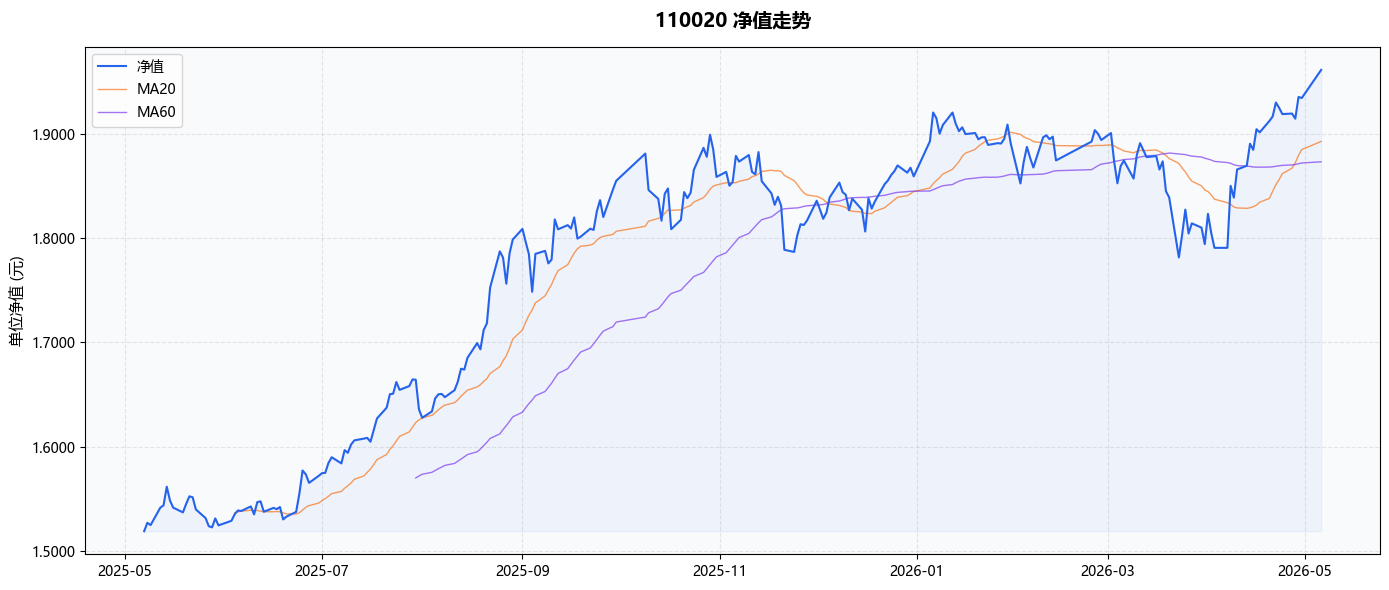

In [6]:
try:
    fig = viz.plot_nav(nav_df, title=f"{FUND_CODE} 净值走势", show_ma=True)
    plt.show()
except Exception as e:
    print(f"⚠️ {e}")

## 5. 看看最大回撤

**最大回撤** = 从最高点跌到最低点的幅度。这是衡量风险的最直观指标。

比如一只基金从 1.5 跌到 1.2，那么这段回撤就是 (1.2 - 1.5) / 1.5 = -20%。

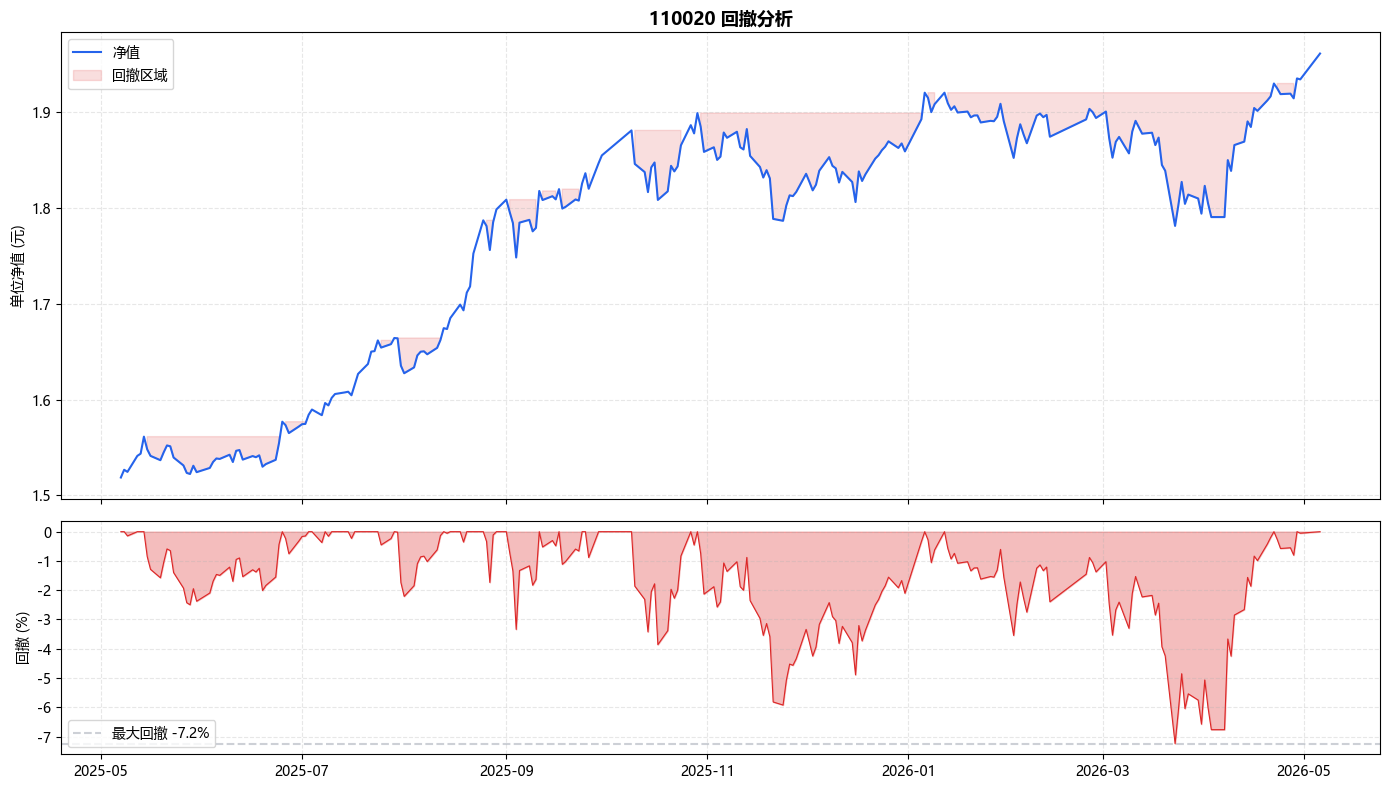


📉 风险指标:
最大回撤: -7.24%
年化波动率: 13.58%
年化收益率: 29.25%
夏普比率: 2.01


In [7]:
try:
    fig = viz.plot_drawdown(nav_df, title=f"{FUND_CODE} 回撤分析")
    plt.show()
    
    # 计算关键风险指标
    rolling_max = nav_df["nav"].cummax()
    drawdown = (nav_df["nav"] - rolling_max) / rolling_max * 100
    max_dd = drawdown.min()
    
    print(f"\n📉 风险指标:")
    print(f"最大回撤: {max_dd:.2f}%")
    print(f"年化波动率: {nav_df['daily_return'].std() * np.sqrt(252) * 100:.2f}%")
    
    # 年化收益
    days = (nav_df["date"].max() - nav_df["date"].min()).days
    if days > 0:
        total_ret = nav_df["nav"].iloc[-1] / nav_df["nav"].iloc[0] - 1
        annual_ret = (1 + total_ret) ** (365 / days) - 1
        print(f"年化收益率: {annual_ret * 100:.2f}%")
        
        # 夏普比率（假设无风险利率 2%）
        excess = annual_ret - 0.02
        vol = nav_df["daily_return"].std() * np.sqrt(252)
        sharpe = excess / vol if vol > 0 else 0
        print(f"夏普比率: {sharpe:.2f}")
except Exception as e:
    print(f"⚠️ {e}")

## 6. 收益分布分析

看看基金的日收益率是如何分布的——大部分日子涨还是跌？

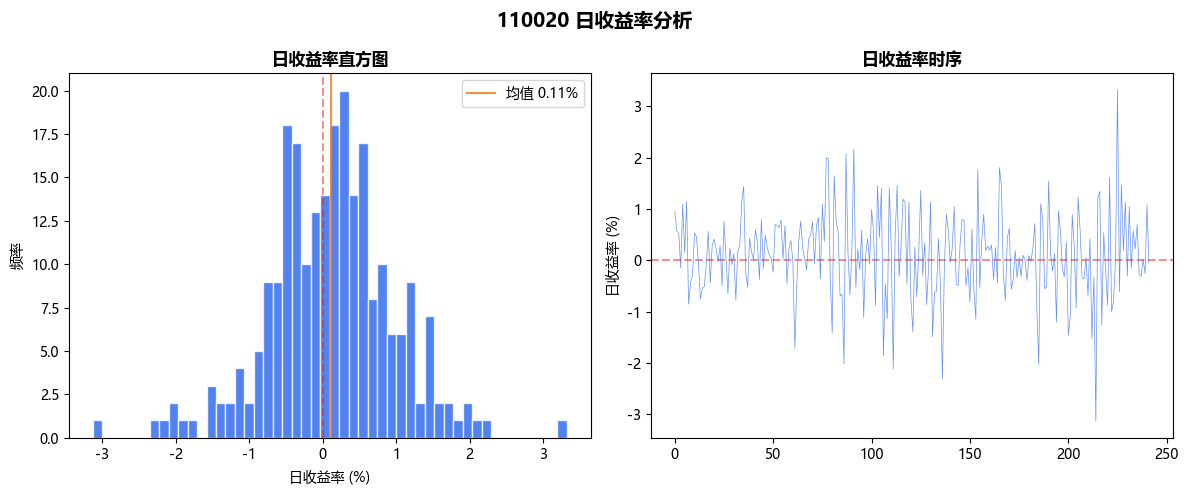


📊 日收益率统计:
上涨天数: 137  (56.6%)
下跌天数: 104  (43.0%)
单日最大涨幅: 3.32%
单日最大跌幅: -3.13%
平均日收益: 0.1100%


In [6]:
try:
    fig = viz.plot_return_distribution(
        nav_df["daily_return"],
        title=f"{FUND_CODE} 日收益率分析"
    )
    plt.show()
    
    returns = nav_df["daily_return"].dropna()
    print(f"\n📊 日收益率统计:")
    print(f"上涨天数: {(returns > 0).sum()}  ({returns.gt(0).mean()*100:.1f}%)")
    print(f"下跌天数: {(returns < 0).sum()}  ({returns.lt(0).mean()*100:.1f}%)")
    print(f"单日最大涨幅: {returns.max()*100:.2f}%")
    print(f"单日最大跌幅: {returns.min()*100:.2f}%")
    print(f"平均日收益: {returns.mean()*100:.4f}%")
except Exception as e:
    print(f"⚠️ {e}")

## 7. 对比多只基金

把你感兴趣的几只基金放在一起对比，看看谁的表现更好。

✅ 沪深300联接 (110020): 242 条数据
✅ 天弘中证500 (001632): 242 条数据
✅ 招商白酒 (161725): 242 条数据


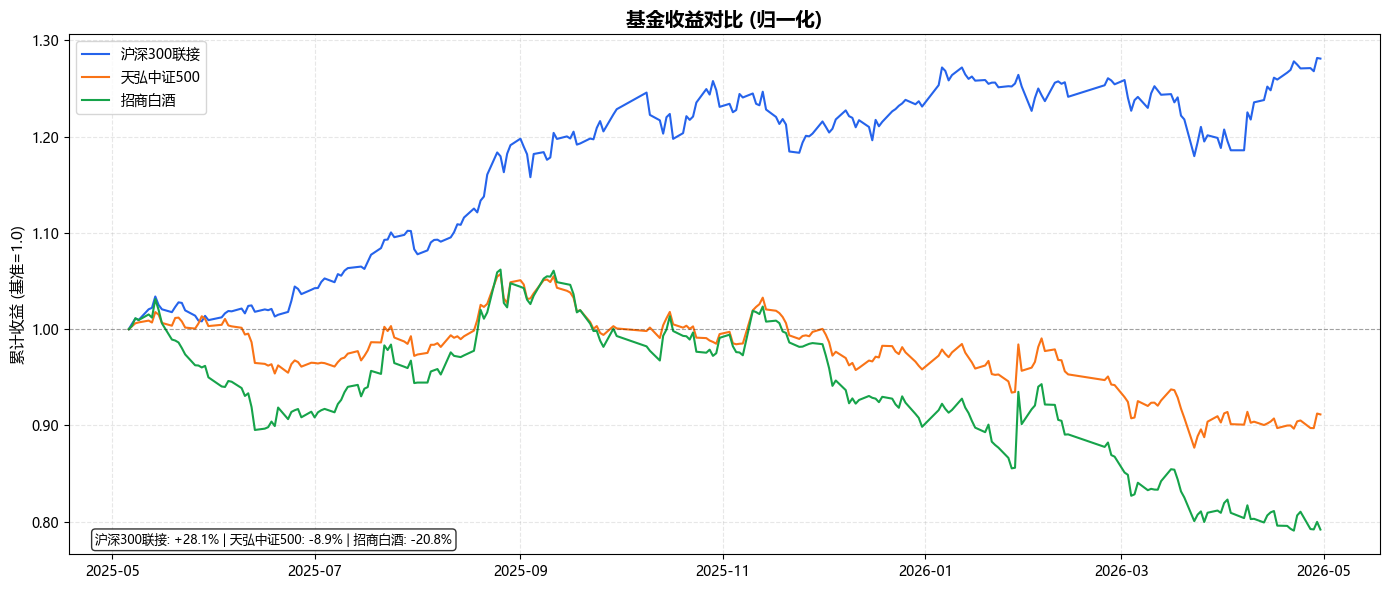

In [7]:
# 定义你想对比的基金
COMPARE_FUNDS = {
    "110020": "沪深300联接",
    "001632": "天弘中证500",
    "161725": "招商白酒",  # 行业基金示例
}

fund_data = {}
for code, label in COMPARE_FUNDS.items():
    try:
        df = get_fund_nav(code)
        fund_data[label] = df
        print(f"✅ {label} ({code}): {len(df)} 条数据")
    except Exception as e:
        print(f"❌ {label} ({code}): {e}")

# 对比图表
if len(fund_data) >= 2:
    fig = viz.plot_comparison(fund_data, title="基金收益对比 (归一化)")
    plt.show()
else:
    print("至少需要2只有效基金才能对比")

## 8. 查看基金收益排名

看看当前市场上哪些基金表现最好。注意：**历史业绩不代表未来表现**。

In [8]:
try:
    # 查看混合型基金排名
    ranking = get_fund_ranking(fund_type="mix", top_n=15)
    print("📊 混合型基金近期收益排名 (前15):\n")
    display(ranking)
except Exception as e:
    print(f"⚠️ {e}")

📊 混合型基金近期收益排名 (前15):



,code,name,return_1w,return_1m,return_3m,return_6m,return_1y,return_2y,return_3y
0,016370,信澳业绩驱动混合A,-3.11,33.23,37.29,64.17,320.83,370.40,235.18
1,016371,信澳业绩驱动混合C,-3.12,33.16,37.09,63.69,318.32,364.88,229.22
2,004320,前海开源沪港深乐享生活,-2.29,41.91,45.57,116.96,314.88,384.94,181.87
3,022364,永赢科技智选混合发起A,-1.69,28.05,22.32,40.83,309.55,NaN,NaN
4,022365,永赢科技智选混合发起C,-1.70,27.99,22.14,40.41,306.97,NaN,NaN
5,008528,华泰柏瑞质量成长A,-3.48,30.09,41.96,84.43,298.14,262.63,152.74
6,018956,中航机遇领航混合发起A,-6.02,26.06,21.88,49.93,297.87,296.65,NaN
7,011452,华泰柏瑞质量成长C,-3.49,30.05,41.74,83.97,296.33,260.02,149.92
8,018957,中航机遇领航混合发起C,-6.03,26.00,21.69,49.48,295.49,291.94,NaN
9,010415,华泰柏瑞质量精选混合A,-3.46,29.63,42.31,76.03,290.87,247.82,164.94


## 9. 动手试试 — 换成你感兴趣的基金

修改下面代码中的基金代码，重复上面的分析。

> 常见基金代码参考：
> - `110020` 易方达沪深300联接
> - `001632` 天弘中证500
> - `000001` 华夏成长混合
> - `050027` 博时信用债纯债
> - `002121` 广发沪港深新起点

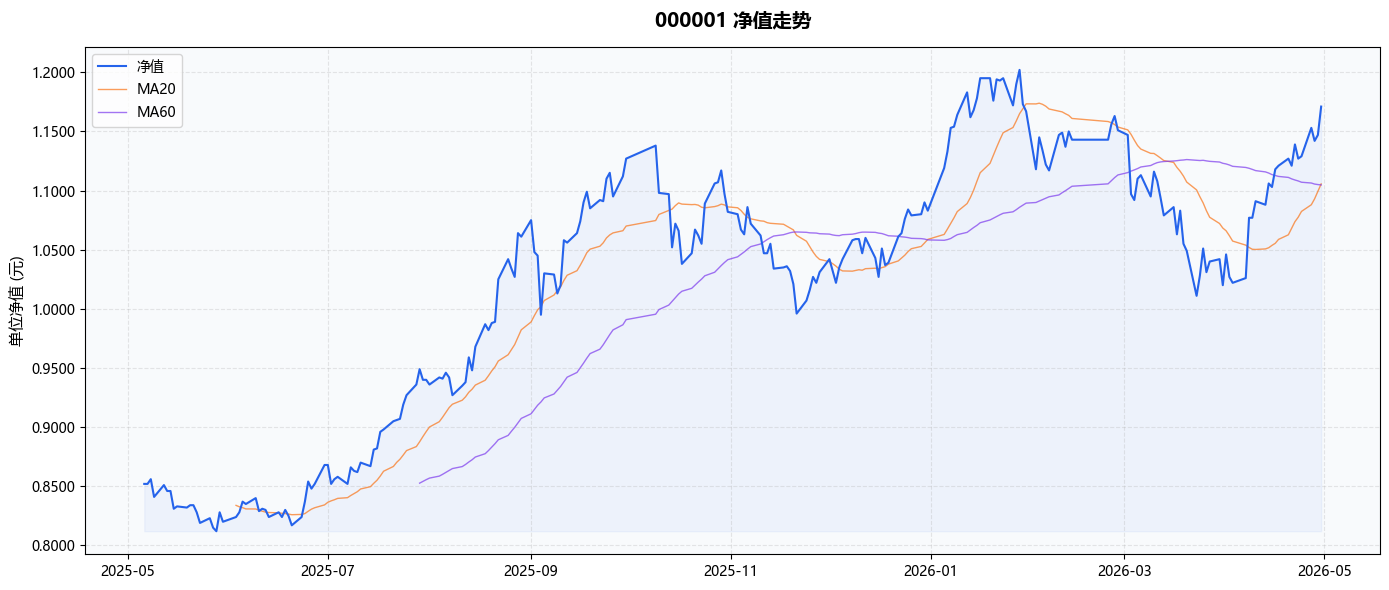

期间收益: +37.44%


In [9]:
# 👇 在这里改成你想研究的基金代码
MY_FUND_CODE = "000001"

try:
    my_nav = get_fund_nav(MY_FUND_CODE)
    fig = viz.plot_nav(my_nav, title=f"{MY_FUND_CODE} 净值走势")
    plt.show()
    
    latest = my_nav.iloc[-1]
    first = my_nav.iloc[0]
    ret = (latest["nav"] - first["nav"]) / first["nav"] * 100
    print(f"期间收益: {ret:+.2f}%")
except Exception as e:
    print(f"⚠️ 可能该基金代码不存在: {e}")

## 📝 本节小结

恭喜！你已经学会了：

- ✅ 获取公募基金列表
- ✅ 查看基金净值走势
- ✅ 分析收益分布和回撤
- ✅ 对比多只基金表现
- ✅ 查看基金排名

### 下一步

- 📖 继续阅读 `knowledge/02-投资入门/01-复利与时间价值.md`
- 📊 打开 `notebooks/02-基金对比与筛选.ipynb` (即将完成)

### 重要提醒
- 历史收益 ≠ 未来收益
- 排名靠前 ≠ 值得买入（可能是追高）
- 多学习、多分析、谨慎决策